Notebook for KPZ surface simulations. 


This notebook modifies the effective time of the simulation. The physics this simulation has to model is long-range spreading at where all source sites try to proliferate at a constant rate. This can be accomplished in two ways:

1) One is to define a single effective time step (ETS) as $\sim L^d$ computational time steps (CTS), where for each CTS, one tries to sample from each lattice site randomly. If a source site is selected, we give it a chance to proliferate with some establishment probability. The important thing about this "sample from all method" is that the rate of proliferation attempts is constant --- the proliferation attempts per ETS scales with the number of source sites in the simulation.
2) Second is to define a single ETS as $1/\text{number of occupied sites}$ CTS, where for each CTS, one samples from the existing source sites at random. Therefore, the the number of proliferation attempts per ETS will still scale with the number of source sites in the simulation. 

For this notebook in particular, we wil only be looking at the standard deviation of the height field in a particular window rather than fitting a line and calculating the MSE. This is because the interface normal is already set by "strip geometry". I'm not really sure about the validity of this statement, but this is what was suggested to me to try.

In [39]:
from __future__ import annotations
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, Iterable, List, Optional, Sequence, Tuple
import matplotlib.pyplot as plt
import numpy as np
import numba
from scipy.ndimage import binary_erosion
from scipy.optimize import curve_fit

**Power jump sampling**. To sample from a jump $r$ from jump distribution $J(r, \mu)$ where $r_0 < r < \infty$, where normalized distribution is
$$
J(r, \mu) = \mu r_0^\mu r^{-(\mu+1)}
$$
we use inverse transform sampling. That is, we draw $F \sim \mathrm{Unif}[0,1]$ and then into the inverse CDF to get a draw $r$ from $J(r, \mu)$:
$$
r = r_0 (1-F)^{-1/\mu}
$$

## Simulation

In [40]:
def sample_power_law_jump(mu: float, rng: np.random.Generator, min_jump: float = np.sqrt(2)) -> float:
    """
    Sample jump distance xi from:
        J(xi, mu) = mu * xi^(-(mu + 1)),  xi >= min_jump
    via inverse transform sampling.

    Returns jump distance r in interval [min_jump, infty]
    """
    if mu <= 0:
        raise ValueError("mu must be > 0 for a normalizable jump distribution.")
    u = rng.random()
    return min_jump * (1.0 - u) ** (-1.0 / mu)

def fit_loglog_slope(x: np.ndarray, y: np.ndarray) -> float:
    """Fit slope in log-log space for positive x, y."""
    mask = (x > 0) & (y > 0) & np.isfinite(x) & np.isfinite(y)
    if np.count_nonzero(mask) < 2:
        return np.nan
    lx = np.log(x[mask])
    ly = np.log(y[mask])
    slope, _ = np.polyfit(lx, ly, deg=1)
    return float(slope)


# ── Numba helpers ────────────────────────────────────────────────────────────

@numba.njit(cache=True)
def _seed_numba_rng(seed: int) -> None:
    """Seed Numba's internal RNG (separate from numpy's Generator)."""
    np.random.seed(seed)


@numba.njit(cache=True)
def _batch_step_kernel(
    grid: np.ndarray,
    occupied_xy: np.ndarray,
    n_occupied: int,
    mu: float,
    L: int,
    grid_rows: int,
    time_acc: float,
    accepted: int,
    n_steps: int,
) -> tuple:
    """Run n_steps growth attempts entirely in compiled Numba code.

    By compiling the inner step loop, all Python interpreter overhead — function
    call dispatch, attribute lookups, int/float boxing — is eliminated. Combined
    with the numpy occupied_xy array (bottleneck #3 fix), every hot-path
    operation is a plain C memory access or arithmetic instruction.

    Uses Numba's internal RNG, seeded separately via _seed_numba_rng.
    Updates grid and occupied_xy in place; returns updated scalar state.

    Args:
        grid:        (grid_rows, L) int8 grid, modified in place.
        occupied_xy: Pre-allocated (capacity, 2) int32 array of (y, x) coords.
        n_occupied:  Current number of occupied sites (active length of occupied_xy).
        mu:          Power-law jump exponent.
        L:           Grid width (columns).
        grid_rows:   Grid height (rows).
        time_acc:    Accumulated physical time so far.
        accepted:    Total occupied sites so far.
        n_steps:     Number of step attempts to run.

    Returns:
        (n_occupied, time_acc, accepted) after n_steps attempts.
    """
    two_pi = 2.0 * np.pi
    for _ in range(n_steps):
        # Sample a random source site from the flat numpy array (O(1), cache-friendly)
        idx = np.random.randint(0, n_occupied)
        sy = occupied_xy[idx, 0]
        sx = occupied_xy[idx, 1]
        pop_id = grid[sy, sx]

        # Power-law jump, min_jump = 1.0
        u = np.random.random()
        jump = (1.0 - u) ** (-1.0 / mu)
        theta = two_pi * np.random.random()
        tx = int(round(sx + jump * np.cos(theta))) % L
        ty = int(round(sy + jump * np.sin(theta)))
        time_acc += 1.0 / accepted

        if ty < 0 or ty >= grid_rows:
            continue
        if grid[ty, tx] != 0:
            continue

        grid[ty, tx] = pop_id
        occupied_xy[n_occupied, 0] = ty
        occupied_xy[n_occupied, 1] = tx
        n_occupied += 1
        accepted += 1

    return n_occupied, time_acc, accepted


@numba.njit(cache=True)
def _sd_width_kernel(
    n_col: np.ndarray,
    sum_y_col: np.ndarray,
    sum_y2_col: np.ndarray,
    ls: np.ndarray,
) -> np.ndarray:
    """Incremental sliding-window SD kernel (see simulation_scratch_wall_time_pure_SD.ipynb)."""
    L = n_col.shape[0]
    widths = np.empty(ls.shape[0])
    for li in range(ls.shape[0]):
        l = ls[li]
        n_w = 0.0; sy = 0.0; sy2 = 0.0
        for k in range(l):
            n_w  += n_col[k]
            sy   += sum_y_col[k]
            sy2  += sum_y2_col[k]
        total_sd = 0.0
        valid = 0
        for x in range(L):
            if n_w > 0.0:
                mean_y = sy / n_w
                var = sy2 / n_w - mean_y * mean_y
                if var < 0.0:
                    var = 0.0
                total_sd += var ** 0.5
                valid += 1
            x_add = (x + l) % L
            n_w  += n_col[x_add]  - n_col[x]
            sy   += sum_y_col[x_add]  - sum_y_col[x]
            sy2  += sum_y2_col[x_add] - sum_y2_col[x]
        widths[li] = total_sd / valid if valid > 0 else np.nan
    return widths


# ── Simulation class ─────────────────────────────────────────────────────────

class StochasticGrowthStripGeometry:
    """Stochastic growth on L by L SQUARE lattice with 2 populations.
    Population A_1 -> 1
    Population A_2 -> 2
    Unoccupied -> 0

    Periodic boundary conditions in x (cylinder geometry).

    Optimizations vs. original:
      - occupied_xy: pre-allocated (capacity, 2) int32 numpy array replaces
        the Python list of tuples. Eliminates heap-allocated tuple objects and
        is directly passable to Numba without conversion.
      - run() delegates to _batch_step_kernel (Numba JIT) which compiles the
        entire step loop to native code, eliminating all Python overhead per step.
    """

    def __init__(self, L: int, mu: float, seed: int = 42):
        if L < 2:
            raise ValueError("L must be at least 2")
        self.L       = int(L)
        self.mu      = float(mu)
        self.rng     = np.random.default_rng(seed)   # used by Python-side methods only
        self.grid    = np.zeros((self.L, self.L), dtype=np.int8)

        self._initialize_strip()

        capacity = self.grid.shape[0] * self.L
        self.occupied_xy = np.zeros((capacity, 2), dtype=np.int32) # holds (y, x) coordinates
        ys, xs = np.where(self.grid > 0)
        self.n_occupied = int(len(ys))
        for i, (y, x) in enumerate(zip(ys, xs)):
            self.occupied_xy[i, 0] = int(y)
            self.occupied_xy[i, 1] = int(x)

        self.time     = 0.0
        self.attempts = 0
        self.accepted = self.L   # initial strip has L occupied sites
        self.history_accepted = [] 
        self.history_attempts = []
        self.history_record_interval = [] # delete later
        self.history_t:              List[float]      = []
        self.history_max_height:     List[float]      = []
        self.history_mean_height:    List[float]      = []
        # self.history_median_height:  List[float]      = []
        self.history_surface_width:  List[np.ndarray] = []
        self.ls: List[int] = []

        # Seed Numba's internal RNG so _batch_step_kernel is reproducible
        _seed_numba_rng(seed)
    
    def __getstate__(self): # this is for saving and loading states
        state = self.__dict__.copy()
        # Only serialize the occupied entries, not the full pre-allocated capacity
        # Otherwise we will be saving L by L array of 32 bit ints
        # for L~10_000 thats around 400 mb per pickle!
        state['occupied_xy'] = self.occupied_xy[:self.n_occupied]
        return state

    def __setstate__(self, state): # this is for saving and loading states
        self.__dict__.update(state)
        # Restore full capacity on load
        capacity = self.grid.shape[0] * self.L
        full = np.zeros((capacity, 2), dtype=np.int32)
        full[:self.n_occupied] = self.occupied_xy
        self.occupied_xy = full
        
    def _initialize_strip(self) -> None:
        half = self.L // 2
        self.grid[0, :half] = 1
        self.grid[0, half:] = 2

    def step(self) -> bool:
        """Single Python-side growth step using the numpy occupied_xy array.

        Kept for debugging and interactive use. Production runs should use
        run(), which calls _batch_step_kernel for the entire loop.
        Note: uses self.rng (Python Generator), not Numba's RNG.
        """
        self.attempts += 1
        idx   = int(self.rng.integers(0, self.n_occupied))
        sy    = int(self.occupied_xy[idx, 0])
        sx    = int(self.occupied_xy[idx, 1])
        pop_id = int(self.grid[sy, sx])

        jump  = sample_power_law_jump(self.mu, self.rng, min_jump=1.0)
        theta = 2.0 * np.pi * self.rng.random()
        tx    = int(round(sx + jump * np.cos(theta))) % self.L
        ty    = int(round(sy + jump * np.sin(theta)))
        self.time += 1.0 / self.accepted

        if ty < 0 or ty >= self.grid.shape[0]:
            return False
        if self.grid[ty, tx] != 0:
            return False

        self.grid[ty, tx] = pop_id
        self.occupied_xy[self.n_occupied, 0] = ty
        self.occupied_xy[self.n_occupied, 1] = tx
        self.n_occupied += 1
        self.accepted   += 1
        return True

    def fill_fraction(self) -> float:
        return float(np.count_nonzero(self.grid) / (self.L * self.L))

    def max_interface_height(self) -> float:
        h = np.zeros(self.L, dtype=np.float64)
        for x in range(self.L):
            ys = np.where(self.grid[:, x] > 0)[0]
            h[x] = ys.max() if ys.size else 0.0
        return float(np.max(h))

    def median_interface_height(self) -> float:
        """Do not use."""
        h = np.zeros(self.L, dtype=np.float64)
        for x in range(self.L):
            ys = np.where(self.grid[:, x] > 0)[0]
            h[x] = ys.max() if ys.size else 0.0
        return float(np.median(h))

    def extract_surface(self) -> np.ndarray:
        binary = (self.grid > 0)
        eroded = binary_erosion(binary, border_value=1)
        return (binary ^ eroded).astype(np.uint8)
    
    def mean_interface_height(self, surface: np.ndarray) -> float:
        ys_idx, _ = np.where(surface > 0)
        return np.mean(ys_idx)

    def extract_surface_width_sd_fast(self, surface: np.ndarray, ls) -> np.ndarray:
        """Compute w(l, t) for each l in ls via Numba incremental SD kernel."""
        L = self.L
        ys_idx, xs_idx = np.where(surface > 0)
        ys_f       = ys_idx.astype(np.float64)
        n_col      = np.bincount(xs_idx, minlength=L).astype(np.float64)
        sum_y_col  = np.bincount(xs_idx, weights=ys_f,      minlength=L)
        sum_y2_col = np.bincount(xs_idx, weights=ys_f ** 2, minlength=L)
        return _sd_width_kernel(n_col, sum_y_col, sum_y2_col, np.asarray(ls, dtype=np.int64))

    def save(self, path: str) -> None:
        """Pickle the full simulation state (grid, histories, RNG state).

        Note: Numba's internal RNG state is NOT preserved by pickle.
        After loading, call _seed_numba_rng(new_seed) if exact reproducibility
        of subsequent steps is required.
        """
        import pickle
        with open(path, "wb") as f:
            pickle.dump(self, f)
        print(f"Simulation saved to {path}  (t={self.time:.4f}, accepted={self.accepted})")

    @classmethod
    def load(cls, path: str) -> "StochasticGrowthStripGeometry":
        import pickle
        with open(path, "rb") as f:
            obj = pickle.load(f)
        print(f"Simulation loaded from {path}  (t={obj.time:.4f}, accepted={obj.accepted})")
        return obj

    def save_snapshot(self, out_dir: Path, t: int, save_png: bool = False) -> None:
        max_height = self.max_interface_height()
        y_bound    = int(3 * max_height)
        out_dir.mkdir(parents=True, exist_ok=True)
        if save_png:
            try:
                import matplotlib.pyplot as plt
            except Exception:
                return
            fig, ax = plt.subplots(figsize=(8, 8), dpi=300)
            cmap = plt.matplotlib.colors.ListedColormap(["white", "#1f77b4", "#d62728"])
            ax.imshow(self.grid[:y_bound, :], origin="lower", cmap=cmap,
                      vmin=0, vmax=2, interpolation="nearest")
            ax.set_title(f"L={self.L}, mu={self.mu}, t={t}")
            ax.set_xlabel("x"); ax.set_ylabel("y")
            fig.tight_layout()
            fig.savefig(out_dir / f"snapshot_t{t:012d}.png")
            plt.close(fig)

    def run(self, n_steps: int, record_interval_true: int = 10,
            ls: list = [],
            snapshot_steps: Optional[Iterable[int]] = None,
            snapshot_dir: Optional[str] = None,
            save_snapshots: bool = False):
        """Run the simulation for n_steps, recording diagnostics every record_interval steps.

        Uses _batch_step_kernel (Numba JIT) to execute record_interval steps at a time,
        then drops back to Python to record diagnostics. This eliminates per-step Python
        overhead while preserving the same recording cadence as the original.

        Note: snapshots fire at the nearest batch boundary, not at exact attempt counts.

        Args:
            n_steps:         Total number of step attempts.
            record_interval: Record interval in the true time. 
            ls:              Window widths for w(l, t) measurement.
            snapshot_steps:  Attempt counts at which to save PNG snapshots.
            snapshot_dir:    Directory to write snapshots into.
            save_snapshots:  Whether to save PNG images at snapshot_steps.
        """
        if not self.ls:
            if not ls:
                raise ValueError("ls has not been specified. Pass ls= to run() or set sim.ls.")
            self.ls = ls

        snapshot_set = set(snapshot_steps or [])
        out_dir      = Path(snapshot_dir) if snapshot_dir else None
        grid_rows    = self.grid.shape[0]
        steps_done   = 0
        record_interval = round(int(record_interval_true**2) * self.L / 2)

        while steps_done < n_steps:
            batch = min(record_interval, n_steps - steps_done)
            print(f"Current progress: {steps_done} of {n_steps} --- {steps_done*100/n_steps:.2f} %", end="\r")

            # Entire batch runs in compiled numba code 
            self.n_occupied, self.time, self.accepted = _batch_step_kernel(
                self.grid, self.occupied_xy, self.n_occupied,
                self.mu, self.L, grid_rows,
                self.time, self.accepted, batch,
            )
            self.attempts += batch
            steps_done    += batch
            

            # Record diagnostics (Python-side, runs infrequently)
            self.history_accepted.append(self.accepted)
            self.history_attempts.append(self.attempts)
            self.history_t.append(self.time)
            self.history_max_height.append(self.max_interface_height())
            # self.history_median_height.append(self.median_interface_height())
            surface = self.extract_surface()
            self.history_surface_width.append(
                self.extract_surface_width_sd_fast(surface, self.ls)
            )
            self.history_mean_height.append(self.mean_interface_height(surface))

            # Update record_interval
            record_interval = int(np.ceil(np.sqrt( 2 * self.attempts * self.L) * record_interval_true +  
                                record_interval_true**2 * self.L / 2))
            self.history_record_interval.append(record_interval)

            # Snapshot: saves snapshot if any attempt in this batch is in snapshot_set
            if out_dir is not None and save_snapshots:
                batch_start = self.attempts - batch
                if snapshot_set & set(range(batch_start, self.attempts)):
                    self.save_snapshot(out_dir, self.attempts, save_png=True)

        return self.get_obs()

    def get_obs(self):
        return {
            "t":                     np.asarray(self.history_t,             dtype=np.float64),
            "t_compute":             np.asarray(self.history_attempts),
            "record_interval":       np.asarray(self.history_record_interval),
            "max_height_history":    np.asarray(self.history_max_height,    dtype=np.float64),
            "mean_height_history":   np.asarray(self.history_mean_height, dtype=np.float64),
            "surface_width_history": np.asarray(self.history_surface_width, dtype=np.float64),
            "population_size":       np.asarray(self.history_accepted),
            "accepted": self.accepted,
        }

In [41]:
# ── Warm-up JIT + correctness + timing benchmark ─────────────────────────────
import time

L_b   = 200
N_b   = 2000
ls_b  = list(range(2, 101))

# Build two identical sims: one original (Python step loop), one optimized (Numba batch)
sim_orig = StochasticGrowthStripGeometry(L=L_b, mu=3.0, seed=99)
sim_fast = StochasticGrowthStripGeometry(L=L_b, mu=3.0, seed=99)

# Warm up Numba JIT (first call compiles; subsequent calls are fast)
_ = sim_fast.run(n_steps=10, record_interval=10, ls=ls_b)

# Run both for N_b steps and compare grid state
t0 = time.perf_counter()
for _ in range(N_b):
    sim_orig.step()
t_orig = time.perf_counter() - t0

sim_fast2 = StochasticGrowthStripGeometry(L=L_b, mu=3.0, seed=99)
_seed_numba_rng(99)
t0 = time.perf_counter()
sim_fast2.run(n_steps=N_b, record_interval=N_b, ls=ls_b)
t_fast = time.perf_counter() - t0

print(f"Python step() x{N_b}: {t_orig*1e3:.1f} ms")
print(f"Numba  batch  x{N_b}: {t_fast*1e3:.1f} ms")
print(f"Speedup: {t_orig/t_fast:.1f}x")
print(f"Accepted sites match: {sim_orig.accepted == sim_fast2.accepted}")


TypeError: StochasticGrowthStripGeometry.run() got an unexpected keyword argument 'record_interval'

## Running, Saving, Loading

In [44]:
# ============================================================
# Initialize new simulation
# ============================================================
sim = StochasticGrowthStripGeometry(L=5_000, mu=5.0, seed=573189)
ls = list(np.logspace(np.log10(100), np.log10(sim.L), num=5, dtype=int))
sim.ls = ls

In [ ]:
# ============================================================
# Save simulation
# ============================================================
sim.save("xxx.pkl") 

In [ ]:
# ============================================================
# Load simulation
# ============================================================
sim_load = StochasticGrowthStripGeometry.load("sim_L5000_mu4p00_t1000M_opt.pkl")
obs = sim_load.get_obs()

FileNotFoundError: [Errno 2] No such file or directory: 'sim_L5000_mu4p00_t1000M_opt.pkl'

In [45]:
# ============================================================
# Run loaded simulation
# ============================================================
obs = sim.run(
    n_steps=200_000_000,
    record_interval_true=5,
    snapshot_steps=[i for i in range(0, 1_000_000_000 + 1, 500_000)],
    snapshot_dir="temp_snapshots_L2000_mu5",
    save_snapshots=True,
)

In [ ]:
# ============================================================
# Save loaded simulation
# ============================================================
sim_load.save("sim_L2500_mu5_t220M.pkl")

In [ ]:
# ============================================================
# Run simulation with checkpoints
# ============================================================
sim_run = sim # change this
step_interval = 5_000_000_000 # number of steps to run before saving simulation state
total_intervals = 10 # total number of intervals to do

starting_time = 0 # if you have loaded in a simulation, this would be the attempt number
record_interval = 2_500_000 # number of timesteps (computational) between statistics.
snapshot_steps = [i for i in range(0, 100_000_000_000 + 1, 25_000_000)] # timesteps at which to save a picture of the simulation

# generate save names
snapshot_dir = f"snapshots_L{sim_run.L}_mu{sim_run.mu:.2f}_opt".replace(".", "p")
save_names = []
for i in range(1, total_intervals + 1):
    time_millions = (starting_time + i*step_interval )// 1_000_000
    save_name = f"sim_L{sim_run.L}_mu{sim_run.mu:.2f}_t{time_millions}M_opt".replace(".", "p") + ".pkl"
    save_names.append(save_name) 

for i in range(total_intervals):
    print(f"Running interval {i}/{total_intervals}")
    obs = sim_run.run(
        n_steps=step_interval,
        record_interval=record_interval,
        snapshot_steps=snapshot_steps,
        snapshot_dir=snapshot_dir,
        save_snapshots=True,
        )
    sim_run.save(save_names[i])

## Data Analysis

In [46]:
def fit_loglog_slope(x: np.ndarray, y: np.ndarray) -> float:
    """Fit slope in log-log space for positive x, y."""
    mask = (x > 0) & (y > 0) & np.isfinite(x) & np.isfinite(y)
    if np.count_nonzero(mask) < 2:
        return np.nan
    lx = np.log(x[mask])
    ly = np.log(y[mask])
    slope, _ = np.polyfit(lx, ly, deg=1)
    return float(slope)

Slope of mean height: 0.9192275431220353
Mean interface power: 1.073907216010371
Max height interface power: 0.8374237634881193


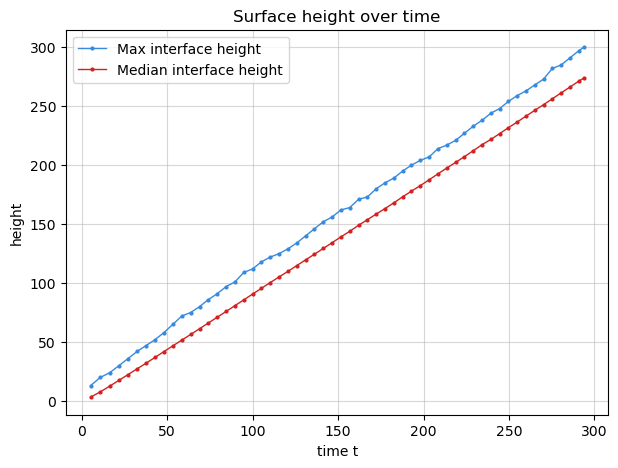

In [47]:
# ============================================================
# plot surface heights over time
# ============================================================
t = obs['t']
max_height = obs['max_height_history']
mean_height = obs['mean_height_history'] 

def model(x, m):
    return m * x + 1 # we know that at time 0, the mean height is 1

popt, pcov = curve_fit(model, t, mean_height) 
m = popt[0]

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(t, max_height, color='#378ADD', lw=1.0, marker='o', markersize=2, label="Max interface height")
ax.plot(t, mean_height, color="#d12121", lw=1.0, marker='o', markersize=2,label="Median interface height")
# ax.set_xscale("log")
# ax.set_yscale("log")
ax.grid(alpha=0.5)
ax.set_xlabel("time t")
ax.set_ylabel("height")
ax.set_title("Surface height over time")
ax.legend()
print(f"Slope of mean height: {m}")
print(f"Mean interface power: {fit_loglog_slope(t, mean_height)}")
print(f"Max height interface power: {fit_loglog_slope(t, max_height)}")

Scaling of effective time versus computational time 0.493454030231951


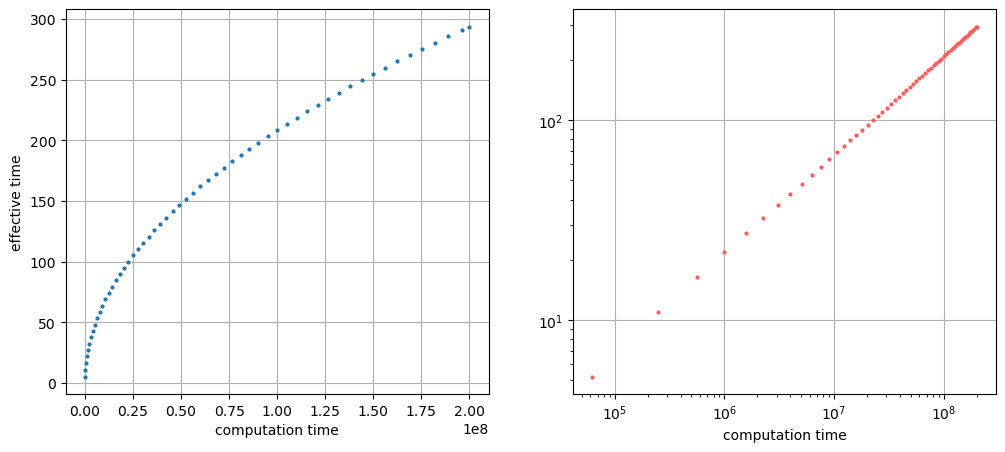

In [48]:
# ============================================================
# plot effective time versus computational time
# ============================================================
t_mean = t
att = obs["t_compute"]
print(f"Scaling of effective time versus computational time {fit_loglog_slope(att, t_mean)}")

fig, ax = plt.subplots(1,2, figsize=(12,5))
ax[0].plot(att, t_mean, marker='o', markersize=2, lw=0)
ax[1].plot(att, t_mean, marker='o', markersize=2, color="#FF5C5C", lw=0)
ax[0].grid(True)
ax[1].grid(True)
ax[0].set_xlabel("computation time")
ax[1].set_xlabel("computation time")
ax[0].set_ylabel("effective time")
ax[1].set_xscale("log")
ax[1].set_yscale("log")

slope: 4629.365162160233
scaling 1.0351313667508852


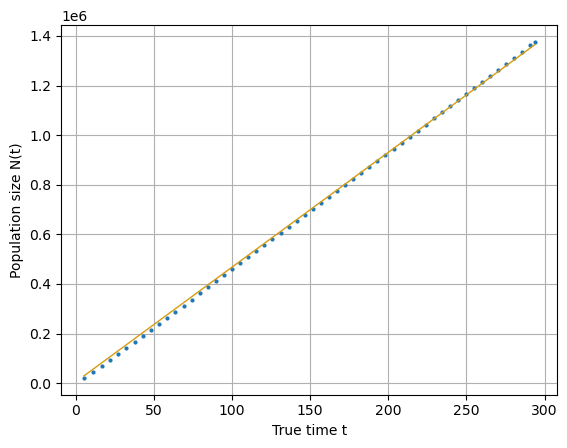

In [49]:
# ============================================================
# plot population size over time
# ============================================================
L = sim.L
def model(x, m):
    return m * x + L

N_t = obs["population_size"]

popt, pcov = curve_fit(model, t, N_t)
m = popt[0]

fig, ax = plt.subplots()
ax.plot(t, N_t, lw=0.0, marker='o', markersize=2)
ax.plot(t, m*t + L, lw=1, color="#D69C12")
ax.grid(True)
ax.set_ylabel("Population size N(t)")
ax.set_xlabel("True time t")
print(f"slope: {m}")
print(f"scaling {fit_loglog_slope(t, N_t)}")

-0.02991180579236151

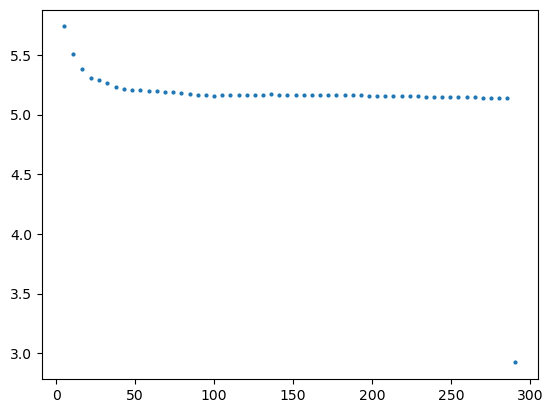

In [50]:
delta_tau = np.asarray([t[i+1]-t[i] for i in range(len(t)-1)])
plt.plot(t[:-1], delta_tau[:], lw=0.0, marker='o', markersize=2)
fit_loglog_slope(t[:-1], delta_tau[:])

To do list:

- Extract the roughness exponent. The function $w(l, t)$ is supposed to saturate given enough time at $w^*(L)$. In this saturation regime, $w^*(L) \sim L^{\beta}$ where $\beta$ is the roughness exponent.
- Extract the dynamical exponent. For fixed $l = l_0$, the width will increase (prior to saturating) as $w(l_0, t) \sim t^{\alpha}$ where $\alpha$ is the growth exponent. Then scaling arguements say that the dynamical exponent is given as $z=\alpha/\beta$.

Mean log-log slope: 0.3218229444105168


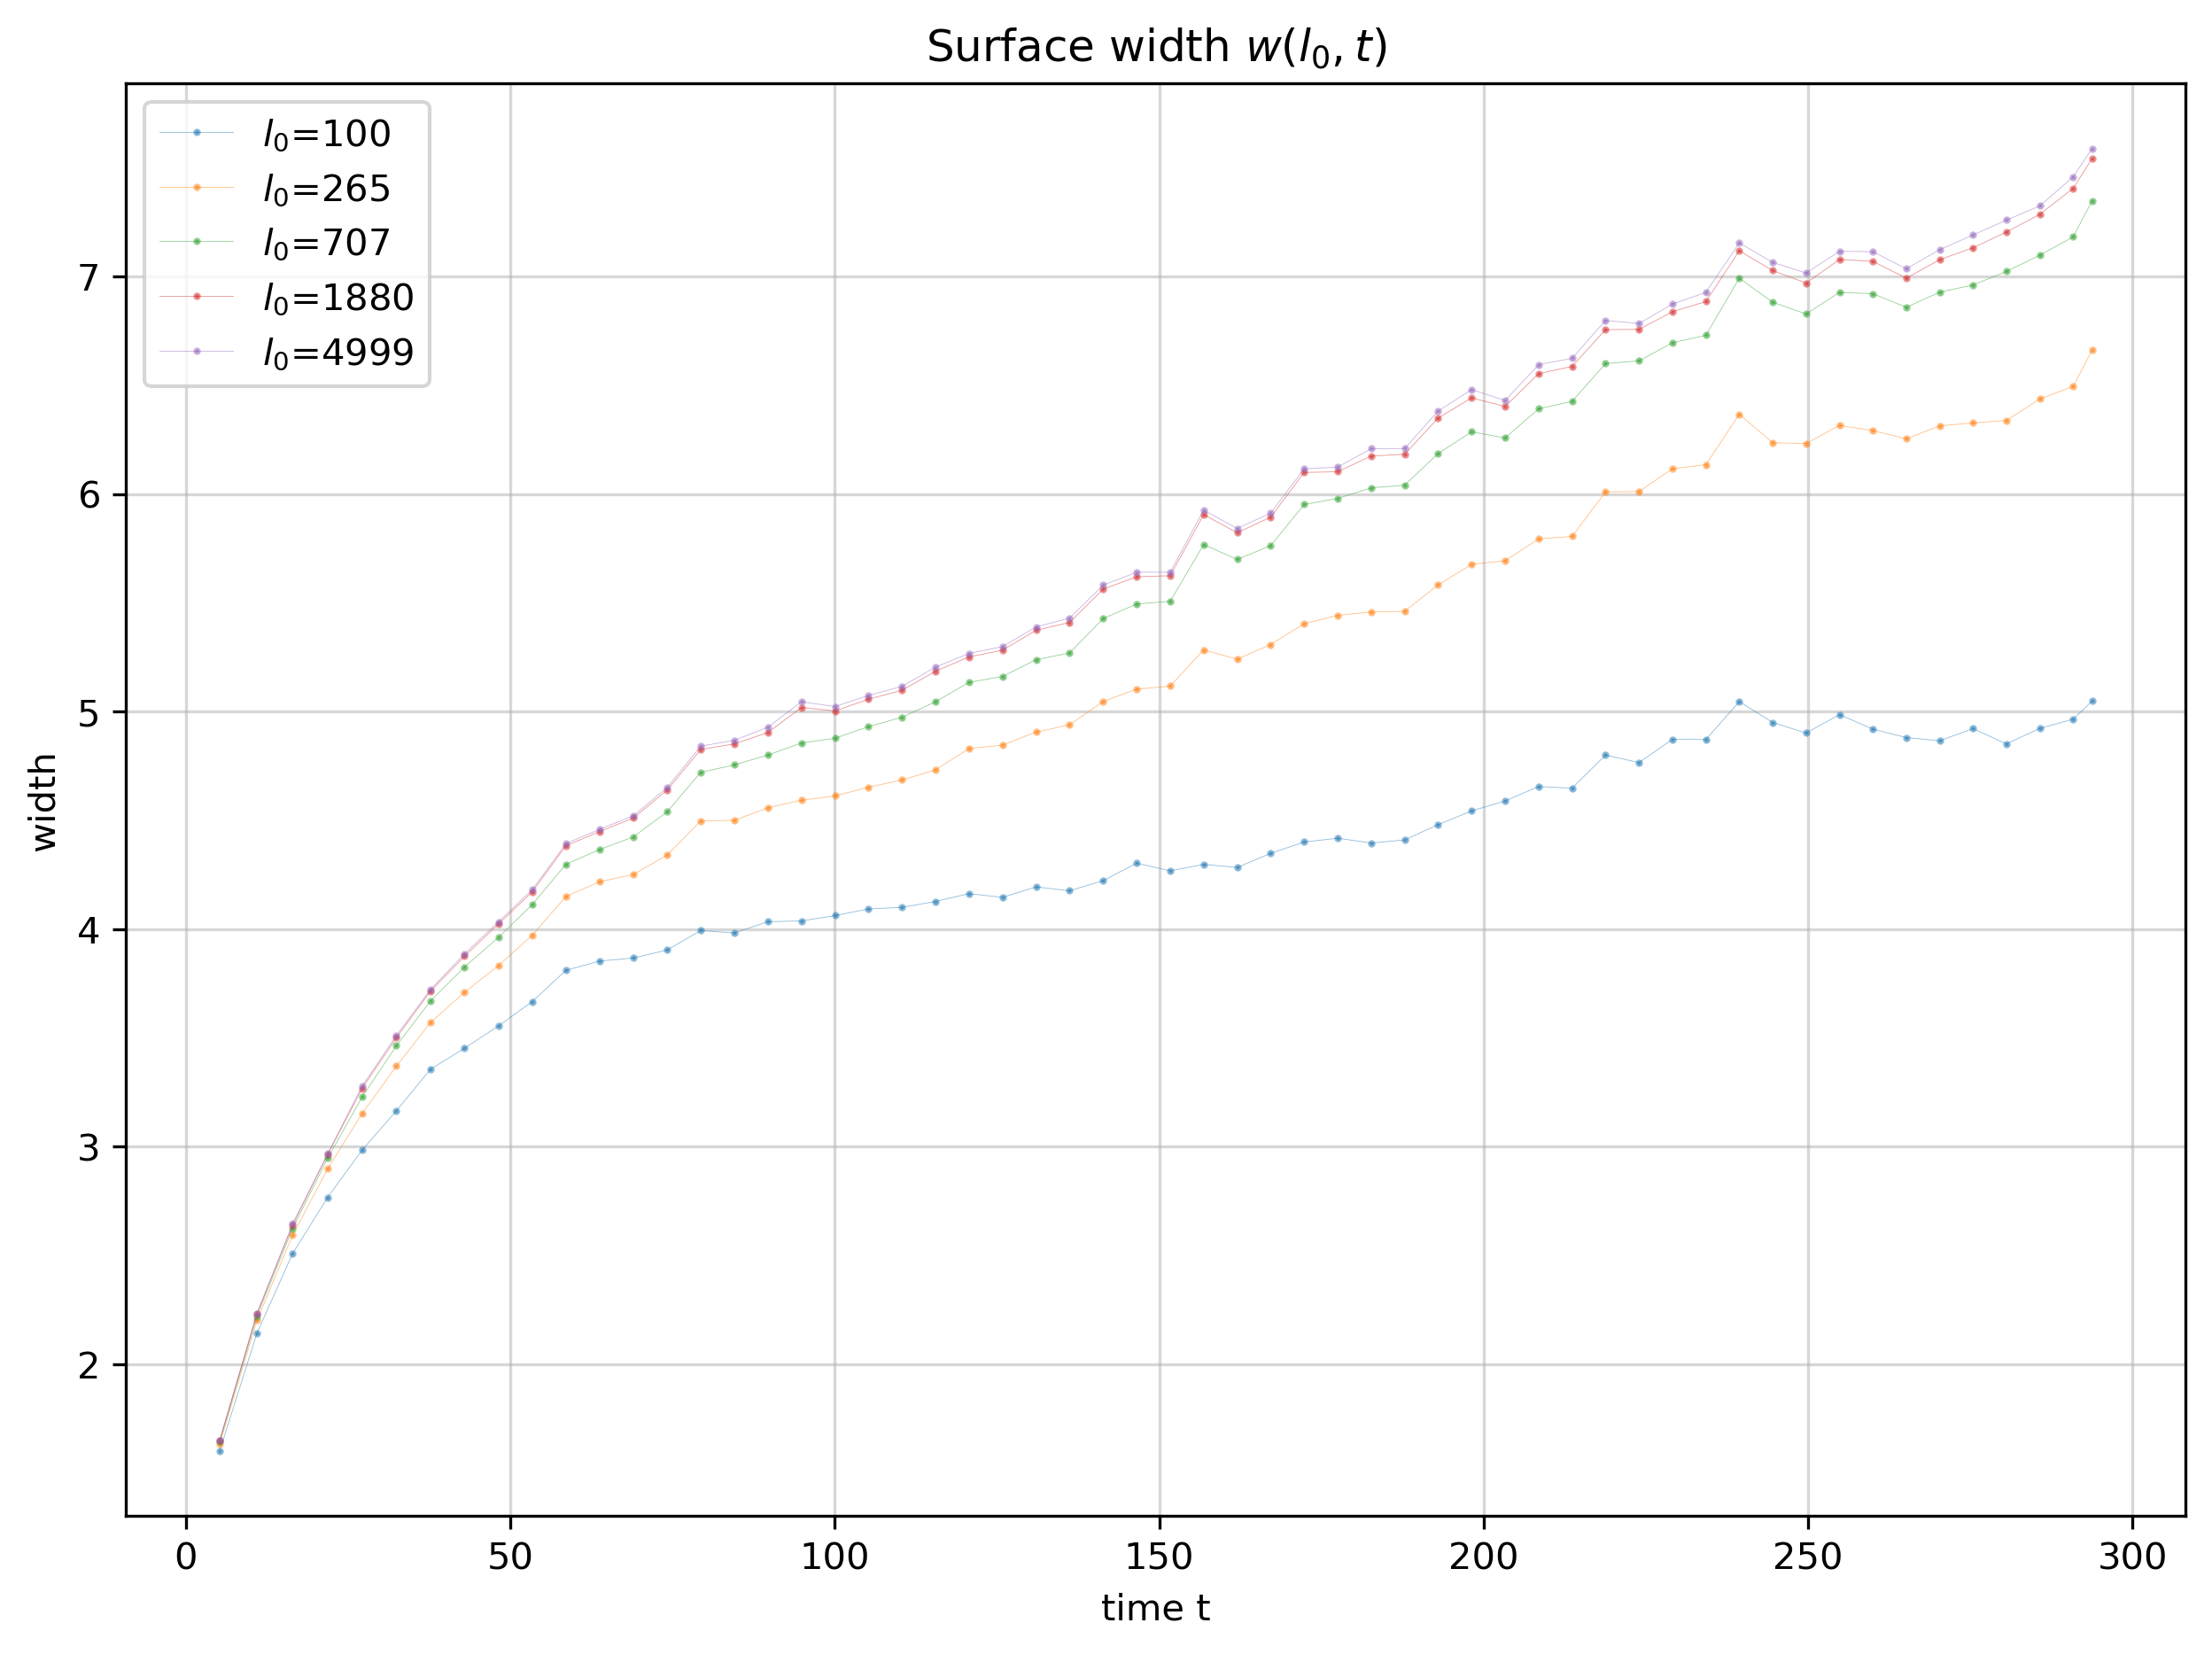

In [51]:
# ============================================================
# plot w(l_0, t) as a function of time
# ============================================================
log_log_slopes = []
t_dim, l_dim = np.shape(obs['surface_width_history'])
l_0s = sim.ls
t = obs['t']
fig, ax = plt.subplots(figsize=(10, 7), dpi=300)
for i, l_0 in enumerate(l_0s):
    w_l_0 = obs['surface_width_history'][:, i]
    log_log_slopes.append(fit_loglog_slope(t, w_l_0))
    ax.plot(t, w_l_0, lw=0.2, label=f"$l_0$={l_0}", alpha=0.5, marker='o', markersize=1)
ax.set_xlabel("time t")
ax.set_ylabel("width")
ax.set_title("Surface width $w(l_0, t)$")
ax.legend()
# ax.set_xscale("log")
# ax.set_yscale("log")
ax.grid(alpha=0.5)
print(f"Mean log-log slope: {np.mean(log_log_slopes)}")

## Notes

The median interface height scales as $h(t) \sim \sqrt{t}$ where $t$ is the number of steps or attempts. In group meeting, it was mentioned that time slows down as you fill up your lattice. Your chances of a successsful jump basically scales inversely proportional to the remaining number of lattice sites. (Maybe I can do a rough calculation of what this is like. I also need to read the SI from Hallatschek's paper to see how he implemented the algorithm.) 

I need to check the code again for computing this "surface roughness"  

Additionally I need to make sure that my "rate" at which I'm populating the lattice sites stays constant, which is achieved by: 
1) Modifying the code to sample from ANY site on the L by L lattice 
2) Modifying the time step to be inversely proportional to the number of occupied sites. 

When modified by the wall time, we should expect this front to grow linearly in time.

## Debugging

In [ ]:

# ============================================================
# Tests for extract_surface_width_standard_deviation
# ============================================================
import traceback

rng = np.random.default_rng(0)

# --- Minimal fake surface for a known answer ---
# L=8, surface sites in a flat band at y=5 (all columns occupied once)
L_test = 8
surface_flat = np.zeros((20, L_test), dtype=np.uint8)
surface_flat[5, :] = 1   # perfectly flat -> SD should be 0 for every window

# Bug 1: syntax error (ßß) — the class definition itself would fail to compile.
# Demonstrated by checking the method actually exists:
sim_test = StochasticGrowthStripGeometry(L=L_test, mu=3.0, seed=0)
print("Bug 1 check – class instantiates (syntax error would prevent this):", type(sim_test))

# Bug 2: avg_y2_window uses `sum_y2_col` (shape 2L,) instead of `sum_y2_window`
# → numpy raises AxisError because sum_y2_col is 1-D, can't sum on axis=1
print("\nBug 2 check – calling extract_surface_width_standard_deviation on flat surface:")
try:
    w = sim_test.extract_surface_width_standard_deviation(surface_flat, l_min=2, l_max=4)
    print("  Returned (no crash):", w)
    print("  Expected all zeros (flat surface → SD=0):", np.allclose(w, 0))
except Exception as e:
    print(f"  CRASHED with {type(e).__name__}: {e}")

# Bug 3: `SDy = np.sqrt(SSy)` is computed but never used;
#         widths[i] = np.mean(np.sqrt(SSy)) recomputes the same thing.
#         Minor redundancy — not a crash, but wasted work.
print("\nBug 3 check (redundant SDy variable): inspect source — SDy is computed but widths[i] calls np.sqrt(SSy) again.")
import inspect
src = inspect.getsource(sim_test.extract_surface_width_standard_deviation)
has_SDy_assigned = "SDy = np.sqrt(SSy)" in src
used_SDy         = "np.mean(SDy)" in src
print(f"  SDy assigned: {has_SDy_assigned}, SDy used in mean: {used_SDy}  (should be True/True after fix)")


In [ ]:
plt.imshow(sim.grid[:50, :10], origin="lower")

In [ ]:
surf = sim.extract_surface()
plt.imshow(surf[:50, :10], origin="lower")

In [ ]:
y_idx, x_idx = np.where(surf[:50, :10] > 0)
n_col = np.bincount(x_idx)
std_true = np.std(y_idx)
y_col = np.bincount(x_idx, y_idx)
y2_col = np.bincount(x_idx, y_idx**2)
mean_y = np.sum(y_col) / np.sum(n_col)
mean_y2 = np.sum(y2_col) / np.sum(n_col)
std_alg = np.sqrt(mean_y2 - mean_y**2)
print(std_true, std_alg) # check

In [ ]:
@numba.njit(cache=True)
def _sd_width_kernel(
    n_col: np.ndarray,
    sum_y_col: np.ndarray,
    sum_y2_col: np.ndarray,
    ls: np.ndarray,
) -> np.ndarray:
    """Incremental sliding-window SD kernel, compiled by Numba.

    For each window width l, maintains three running sums (n, Σy, Σy²) and
    updates them in O(1) as the window shifts one column right:
        remove exiting column x, add entering column (x + l) % L.

    This is O(L) per l value vs the numpy version's O(L·l) from
    sliding_window_view + sum(axis=1), and allocates no large intermediates.

    Args:
        n_col:      Per-column surface-site counts,  shape (L,).
        sum_y_col:  Per-column Σy,                   shape (L,).
        sum_y2_col: Per-column Σy²,                  shape (L,).
        ls:         1-D int64 array of window widths.

    Returns:
        Array of shape (len(ls),) with mean SD per window width.
    """
    L = n_col.shape[0]
    widths = np.empty(ls.shape[0])

    for li in range(ls.shape[0]):
        l = ls[li]

        # Initialise first window [0, l)
        n_w = 0.0; sy = 0.0; sy2 = 0.0
        for k in range(l):
            n_w  += n_col[k]
            sy   += sum_y_col[k]
            sy2  += sum_y2_col[k]

        total_sd = 0.0
        valid = 0

        for x in range(L):
            if n_w > 0.0:
                mean_y = sy / n_w
                var = sy2 / n_w - mean_y * mean_y
                if var < 0.0:
                    var = 0.0
                total_sd += var ** 0.5
                valid += 1

            # O(1) slide: remove column x, add column (x + l) % L
            x_add = (x + l) % L
            n_w  += n_col[x_add]  - n_col[x]
            sy   += sum_y_col[x_add]  - sum_y_col[x]
            sy2  += sum_y2_col[x_add] - sum_y2_col[x]

        widths[li] = total_sd / valid if valid > 0 else np.nan

    return widths


def _extract_surface_width_sd_fast(self, surface: np.ndarray, ls) -> np.ndarray:
    """Fast drop-in for extract_surface_width_standard_deviation.

    Delegates to _sd_width_kernel (Numba JIT). O(L) per window width instead
    of O(L·l) — no large intermediate arrays. First call triggers JIT compilation.
    """
    L = self.L
    ys_idx, xs_idx = np.where(surface > 0)
    ys_f       = ys_idx.astype(np.float64)
    n_col      = np.bincount(xs_idx, minlength=L).astype(np.float64)
    sum_y_col  = np.bincount(xs_idx, weights=ys_f,       minlength=L)
    sum_y2_col = np.bincount(xs_idx, weights=ys_f ** 2,  minlength=L)
    return _sd_width_kernel(n_col, sum_y_col, sum_y2_col, np.asarray(ls, dtype=np.int64))

StochasticGrowthStripGeometry.extract_surface_width_sd_fast = _extract_surface_width_sd_fast


# ── Correctness + timing check ───────────────────────────────────────────────
import time

sim_bench = StochasticGrowthStripGeometry(L=200, mu=3.0, seed=7)
for _ in range(2000):
    sim_bench.step()
surf_bench = sim_bench.extract_surface()
ls_bench   = list(range(2, 101))

# Warm-up JIT
_ = sim_bench.extract_surface_width_sd_fast(surf_bench, ls_bench)

w_old = sim_bench.extract_surface_width_standard_deviation(surf_bench, ls_bench)
w_new = sim_bench.extract_surface_width_sd_fast(surf_bench, ls_bench)
print("Results match:", np.allclose(w_old, w_new, rtol=1e-10))

N = 50
t0 = time.perf_counter()
for _ in range(N):
    sim_bench.extract_surface_width_standard_deviation(surf_bench, ls_bench)
t_old = (time.perf_counter() - t0) / N

t0 = time.perf_counter()
for _ in range(N):
    sim_bench.extract_surface_width_sd_fast(surf_bench, ls_bench)
t_new = (time.perf_counter() - t0) / N

print(f"Old: {t_old*1e3:.2f} ms  |  New: {t_new*1e3:.2f} ms  |  Speedup: {t_old/t_new:.1f}x")
